# Parcel-wise independent Welch t-tests

Compare expW weighted degree between Healthy and Unhealthy subjects at each parcel.

Use the Healthy and Unhealthy subjects from the JSON test cohorts that have graph outputs. BH-FDR controls multiple comparisons across parcels.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests

PROJECT_ROOT = next(
    folder for folder in (Path.cwd(), *Path.cwd().parents)
    if (folder / "data" / "database_finale_labels_corrette.csv").is_file()
)
DATA_FILE = PROJECT_ROOT / "data" / "database_finale_labels_corrette.csv"
SPLITS_FILE = PROJECT_ROOT / "data" / "splits.json"
RUN_ROOT = PROJECT_ROOT / "outputs" / "cohorts" / "oasis3" / "runs" / "connected-atlas-8cf3dc8f"
FEATURE_ROOT = RUN_ROOT / "graphs" / "unthresholded" / "was" / "expW"
RESULTS_DIR = RUN_ROOT / "statistics" / "unthresholded"


In [2]:
available_subjects = {
    folder.name
    for folder in FEATURE_ROOT.glob("sub-*")
    if (folder / "weighted_degree.dat").is_file()
}

splits = json.loads(SPLITS_FILE.read_text())
test_healthy = {f"sub-{item}" for item in splits["test_healthy"]}
test_unhealthy = {f"sub-{item}" for item in splits["test_unhealthy"]}
selected_healthy = sorted(test_healthy & available_subjects)
selected_unhealthy = sorted(test_unhealthy & available_subjects)

database = pd.read_csv(DATA_FILE)
database["subject_id"] = "sub-" + database["OASISID"].astype(str).str.removeprefix("OAS3")

len(selected_healthy), len(selected_unhealthy)

(137, 130)

In [3]:
subjects = selected_healthy + selected_unhealthy
parcel_ids = (FEATURE_ROOT / subjects[0] / "parcel_order.txt").read_text().splitlines()
parcel_count = len(parcel_ids)

def load_group(subject_ids):
    return np.vstack([
        np.fromfile(FEATURE_ROOT / subject / "weighted_degree.dat", dtype=np.float64)
        for subject in subject_ids
    ])

healthy = load_group(selected_healthy)
unhealthy = load_group(selected_unhealthy)
healthy.shape, unhealthy.shape

((137, 83442), (130, 83442))

In [4]:
welch = stats.ttest_ind(
    unhealthy,
    healthy,
    axis=0,
    equal_var=False,
    alternative="two-sided",
)
# Replace NaN p-values with 1.0 to avoid issues with multiple testing correction
welch_p = np.where(np.isfinite(welch.pvalue), welch.pvalue, 1.0)

# Perform multiple testing correction using Benjamini-Hochberg FDR
welch_q = multipletests(welch_p, method="fdr_bh")[1]
survives_fdr = welch_q < 0.05

healthy_mean = healthy.mean(axis=0)
unhealthy_mean = unhealthy.mean(axis=0)
mean_difference = unhealthy_mean - healthy_mean

healthy_var = healthy.var(axis=0, ddof=1)
unhealthy_var = unhealthy.var(axis=0, ddof=1)

pooled_sd = np.sqrt(
    ((len(healthy) - 1) * healthy_var + (len(unhealthy) - 1) * unhealthy_var)
    / (len(healthy) + len(unhealthy) - 2)
)
cohens_d = np.divide(
    mean_difference,
    pooled_sd,
    out=np.full(parcel_count, np.nan),
    where=pooled_sd > 0,
)
hedges_g = cohens_d * (
    1 - 3 / (4 * (len(healthy) + len(unhealthy)) - 9)
)

results_weighted_degree = pd.DataFrame({
    "parcel_id": parcel_ids,
    "healthy_mean": healthy_mean,
    "unhealthy_mean": unhealthy_mean,
    "mean_group_difference": mean_difference,
    "hedges_g": hedges_g,
    "welch_t_statistic": welch.statistic,
    "welch_p": welch_p,
    "welch_q_bh": welch_q,
    "welch_survives_fdr": survives_fdr,
})

summary = pd.DataFrame([{
    "comparison": "Independent Welch t-test: Unhealthy vs Healthy",
    "healthy_subjects": len(healthy),
    "unhealthy_subjects": len(unhealthy),
    "parcels": parcel_count,
    "surviving_parcels_bh_fdr_0.05": int(survives_fdr.sum()),
    "percent_of_all_parcels": 100 * survives_fdr.mean(),
}])
summary.round(2)

,comparison,healthy_subjects,unhealthy_subjects,parcels,surviving_parcels_bh_fdr_0.05,percent_of_all_parcels
0,Independent Welch t-test: Unhealthy vs Healthy,137,130,83442,1371,1.64


In [5]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
parcel_file = RESULTS_DIR / "weighted_degree_expW_independent_welch_tests.csv"
summary_file = RESULTS_DIR / "weighted_degree_expW_independent_welch_summary.csv"

results_weighted_degree.to_csv(parcel_file, index=False)
summary.to_csv(summary_file, index=False)

display(results_weighted_degree.sort_values("welch_q_bh").head(10).round(6))
pd.Series({"parcel_results": parcel_file, "summary": summary_file})

,parcel_id,healthy_mean,unhealthy_mean,mean_group_difference,hedges_g,welch_t_statistic,welch_p,welch_q_bh,welch_survives_fdr
32855,label_18/roi_0053,0.735917,0.704867,-0.031050,-0.733127,-5.932607,0.0,0.001007,True
75564,label_43/roi_0152,0.677349,0.591422,-0.085927,-0.650609,-5.272085,0.0,0.002352,True
80798,label_49/roi_0056,0.719865,0.681717,-0.038148,-0.643952,-5.219169,0.0,0.002352,True
83421,label_60/roi_0378,0.734205,0.710640,-0.023566,-0.657532,-5.335284,0.0,0.002352,True
32887,label_18/roi_0085,0.740154,0.711726,-0.028429,-0.694173,-5.592703,0.0,0.002352,True
32854,label_18/roi_0052,0.736023,0.705496,-0.030527,-0.675552,-5.454683,0.0,0.002352,True
81309,label_49/roi_0567,0.680985,0.618769,-0.062216,-0.655240,-5.313192,0.0,0.002352,True
81209,label_49/roi_0467,0.720928,0.679848,-0.041080,-0.660043,-5.336314,0.0,0.002352,True
81240,label_49/roi_0498,0.727440,0.698707,-0.028733,-0.646888,-5.235997,0.0,0.002352,True
10753,label_3/roi_10753,0.702429,0.655978,-0.046451,-0.658052,-5.324243,0.0,0.002352,True


parcel_results    /home/lucagalli/Projects/parcellating_dbm/outp...
summary           /home/lucagalli/Projects/parcellating_dbm/outp...
dtype: object

## Mean Investigation Fine Grained

In [6]:
MEANS_ROOT = RUN_ROOT / "parcel_vectors"

In [7]:
def load_direct_mean_matrix(subject_ids):
    return np.vstack([
        np.fromfile(MEANS_ROOT / subject / "direct_mean.dat", dtype=np.float64)
        for subject in subject_ids
    ])

healthy = load_direct_mean_matrix(selected_healthy)
unhealthy = load_direct_mean_matrix(selected_unhealthy)

In [21]:
healthy[1]

array([-0.1888233 ,  0.48529087,  0.03778341, ..., -0.00409996,
        0.49194201, -0.02341978], shape=(83442,))

In [8]:
welch = stats.ttest_ind(
    unhealthy,
    healthy,
    axis=0,
    equal_var=False,
    alternative="two-sided",
)
welch_p = np.where(np.isfinite(welch.pvalue), welch.pvalue, 1.0)
welch_q = multipletests(welch_p, method="fdr_bh")[1]
survives_fdr = welch_q < 0.05

healthy_mean = healthy.mean(axis=0)
unhealthy_mean = unhealthy.mean(axis=0)
mean_difference = unhealthy_mean - healthy_mean
healthy_var = healthy.var(axis=0, ddof=1)
unhealthy_var = unhealthy.var(axis=0, ddof=1)

pooled_sd = np.sqrt(
    ((len(healthy) - 1) * healthy_var + (len(unhealthy) - 1) * unhealthy_var)
    / (len(healthy) + len(unhealthy) - 2)
)
cohens_d = np.divide(
    mean_difference,
    pooled_sd,
    out=np.full(parcel_count, np.nan),
    where=pooled_sd > 0,
)
hedges_g = cohens_d * (
    1 - 3 / (4 * (len(healthy) + len(unhealthy)) - 9)
)

results_means_fine_grained = pd.DataFrame({
    "parcel_id": parcel_ids,
    "healthy_mean": healthy_mean,
    "unhealthy_mean": unhealthy_mean,
    "mean_group_difference": mean_difference,
    "hedges_g": hedges_g,
    "welch_t_statistic": welch.statistic,
    "welch_p": welch_p,
    "welch_q_bh": welch_q,
    "welch_survives_fdr": survives_fdr,
})

summary = pd.DataFrame([{
    "comparison": "Independent Welch t-test: Unhealthy vs Healthy",
    "healthy_subjects": len(healthy),
    "unhealthy_subjects": len(unhealthy),
    "parcels": parcel_count,
    "surviving_parcels_bh_fdr_0.05": int(survives_fdr.sum()),
    "percent_of_all_parcels": 100 * survives_fdr.mean(),
}])
summary.round(2)


,comparison,healthy_subjects,unhealthy_subjects,parcels,surviving_parcels_bh_fdr_0.05,percent_of_all_parcels
0,Independent Welch t-test: Unhealthy vs Healthy,137,130,83442,1256,1.51


In [9]:
display(results_means_fine_grained.sort_values("welch_q_bh").head(10).round(6))

,parcel_id,healthy_mean,unhealthy_mean,mean_group_difference,hedges_g,welch_t_statistic,welch_p,welch_q_bh,welch_survives_fdr
11585,label_3/roi_11585,0.149056,0.041345,-0.107711,-0.823035,-6.697978,0.0,0.000012,True
11118,label_3/roi_11118,0.032276,-0.086254,-0.118530,-0.782025,-6.367371,0.0,0.000039,True
82862,label_54/roi_0060,0.250280,0.130787,-0.119492,-0.777982,-6.308898,0.0,0.000041,True
64523,label_42/roi_12158,0.069480,-0.031741,-0.101221,-0.742085,-6.034652,0.0,0.000100,True
82872,label_54/roi_0070,0.211625,0.080453,-0.131171,-0.748811,-6.069943,0.0,0.000100,True
10563,label_3/roi_10563,0.025340,-0.083441,-0.108781,-0.734836,-5.965875,0.0,0.000126,True
21793,label_3/roi_21793,-0.004409,-0.122493,-0.118083,-0.722127,-5.891269,0.0,0.000144,True
82852,label_54/roi_0050,0.300376,0.170895,-0.129481,-0.721032,-5.838279,0.0,0.000179,True
10824,label_3/roi_10824,0.011881,-0.103340,-0.115221,-0.718327,-5.838529,0.0,0.000179,True
32902,label_18/roi_0100,0.079602,-0.036006,-0.115608,-0.700820,-5.682976,0.0,0.000228,True


In [10]:
selected_subjects = selected_healthy + selected_unhealthy

covariates_of_interest = [
    "subject_id",
    "age at visit",
    "GENDER",
    "EDUC",
    "HStatus",
]

database_covariates = (
    database[covariates_of_interest]
    .set_index("subject_id")
    .reindex(selected_subjects)
    .copy()
)

database_covariates["group"] = database_covariates["HStatus"].map(
    {"Healthy": 0, "Unhealthy": 1}
)

database_covariates["male"] = database_covariates["GENDER"].map(
    {"Female": 0, "Male": 1}
)
database_covariates

,age at visit,GENDER,EDUC,HStatus,group,male
subject_id,,,,,,
sub-0002,67.25,Male,18.0,Healthy,0,1
sub-0003,58.81,Female,18.0,Healthy,0,0
sub-0010,68.44,Female,18.0,Healthy,0,0
sub-0014,70.39,Female,18.0,Healthy,0,0
sub-0055,72.58,Male,16.0,Healthy,0,1
...,...,...,...,...,...,...
sub-1405,55.61,Male,12.0,Unhealthy,1,1
sub-1416,74.07,Female,18.0,Unhealthy,1,0
sub-1424,68.44,Female,12.0,Unhealthy,1,0


In [11]:
# Rows: Healthy subjects first, then Unhealthy subjects
Y = np.vstack([healthy, unhealthy])

# Keep subjects with complete covariate data
model_columns = ["group", "age at visit", "male", "EDUC"]
keep = database_covariates[model_columns].notna().all(axis=1).to_numpy()

covariates = database_covariates.loc[keep]
Y = Y[keep]

# Centre and scale continuous covariates
age = covariates["age at visit"].to_numpy(dtype=float)
education = covariates["EDUC"].to_numpy(dtype=float)

age = (age - age.mean()) / age.std(ddof=1)
education = (
    (education - education.mean())
    / education.std(ddof=1)
)

# Design matrix:
# intercept, unhealthy group, age, male sex, education
X = np.column_stack([
    np.ones(len(covariates)),
    covariates["group"].to_numpy(dtype=float),
    age,
    covariates["male"].to_numpy(dtype=float),
    education,
])

# Fit all 83,442 parcel models simultaneously
xtx_inverse = np.linalg.pinv(X.T @ X)
beta = xtx_inverse @ X.T @ Y

residuals = Y - X @ beta
degrees_of_freedom = len(Y) - X.shape[1]

residual_variance = (
    np.sum(residuals ** 2, axis=0)
    / degrees_of_freedom
)

group_se = np.sqrt(
    residual_variance * xtx_inverse[1, 1]
)

group_t = np.divide(
    beta[1],
    group_se,
    out=np.full(parcel_count, np.nan),
    where=group_se > 0,
)

group_p = 2 * stats.t.sf(
    np.abs(group_t),
    degrees_of_freedom,
)

group_q = multipletests(
    group_p,
    method="fdr_bh",
)[1]

glm_results = pd.DataFrame({
    "parcel_id": parcel_ids,
    "glm_beta_unhealthy": beta[1],
    "glm_t_unhealthy": group_t,
    "glm_p_value": group_p,
    "glm_q_bh": group_q,
    "glm_survives_fdr": group_q < 0.05,
})

glm_results.sort_values("glm_q_bh")

,parcel_id,glm_beta_unhealthy,glm_t_unhealthy,glm_p_value,glm_q_bh,glm_survives_fdr
11118,label_3/roi_11118,-0.112744,-6.312539,1.166863e-09,0.000049,True
11585,label_3/roi_11585,-0.102987,-6.382214,7.881886e-10,0.000049,True
82862,label_54/roi_0060,-0.109357,-6.109650,3.595537e-09,0.000100,True
64523,label_42/roi_12158,-0.101298,-6.044503,5.132365e-09,0.000107,True
10563,label_3/roi_10563,-0.101150,-5.849737,1.463336e-08,0.000244,True
...,...,...,...,...,...,...
71144,label_42/roi_18779,0.000005,0.000189,9.998497e-01,0.999966,False
38875,label_24/roi_5918,-0.000029,-0.000640,9.994901e-01,0.999966,False
15840,label_3/roi_15840,-0.000028,-0.000523,9.995834e-01,0.999966,False
40701,label_24/roi_7744,0.000019,0.000447,9.996433e-01,0.999966,False


In [12]:
glm_results["glm_survives_fdr"].sum()

np.int64(469)

In [13]:

# results_weighted_degree = risultati del t-test Wasserstein weighted degree
# results_means_fine_grained = risultati del t-test delle medie Jacobiane dirette

comparison = (
    results_means_fine_grained[
        ["parcel_id", "welch_t_statistic"]
    ]
    .merge(
        results_weighted_degree[["parcel_id", "welch_t_statistic"]],
        on="parcel_id",
        suffixes=("_jacobian", "_weighted_degree"),
        validate="one_to_one",
    )
)

valid = comparison.dropna()

pearson = stats.pearsonr(
    valid["welch_t_statistic_jacobian"],
    valid["welch_t_statistic_weighted_degree"],
)

print(f"Numero di microparcelle: {len(valid)}")
print(f"Pearson r = {pearson.statistic:.4f}")
print(f"p-value   = {pearson.pvalue:.3e}")

Numero di microparcelle: 83442
Pearson r = -0.0161
p-value   = 3.508e-06


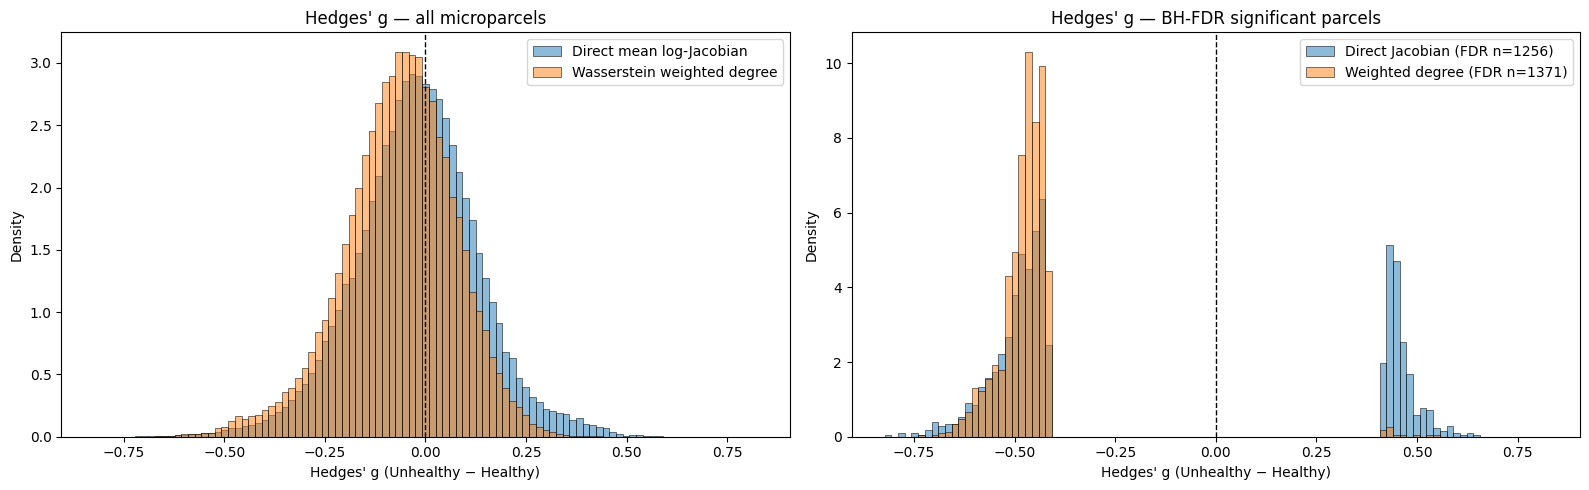

In [14]:
# results_weighted_degree = Wasserstein weighted-degree t-test results_weighted_degree
# results_means_fine_grained = direct mean log-Jacobian t-test results_weighted_degree

g_jacobian = results_means_fine_grained["hedges_g"].dropna()
g_weighted_degree = results_weighted_degree["hedges_g"].dropna()

# Same x-axis and bins for a fair visual comparison
limit = max(np.abs(g_jacobian).max(), np.abs(g_weighted_degree).max())
bins = np.linspace(-limit, limit, 100)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True)

# All 83k parcels
sns.histplot(
    g_jacobian,
    bins=bins,
    stat="density",
    alpha=0.5,
    color="tab:blue",
    label="Direct mean log-Jacobian",
    ax=axes[0],
)
sns.histplot(
    g_weighted_degree,
    bins=bins,
    stat="density",
    alpha=0.5,
    color="tab:orange",
    label="Wasserstein weighted degree",
    ax=axes[0],
)
axes[0].axvline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Hedges' g — all microparcels")
axes[0].set_xlabel("Hedges' g (Unhealthy − Healthy)")
axes[0].set_ylabel("Density")
axes[0].legend()

# Only BH-FDR significant parcels
g_jacobian_fdr = results_means_fine_grained.loc[
    results_means_fine_grained["welch_survives_fdr"],
    "hedges_g",
].dropna()

g_weighted_degree_fdr = results_weighted_degree.loc[
    results_weighted_degree["welch_survives_fdr"],
    "hedges_g",
].dropna()

sns.histplot(
    g_jacobian_fdr,
    bins=bins,
    stat="density",
    alpha=0.5,
    color="tab:blue",
    label=f"Direct Jacobian (FDR n={len(g_jacobian_fdr)})",
    ax=axes[1],
)
sns.histplot(
    g_weighted_degree_fdr,
    bins=bins,
    stat="density",
    alpha=0.5,
    color="tab:orange",
    label=f"Weighted degree (FDR n={len(g_weighted_degree_fdr)})",
    ax=axes[1],
)
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Hedges' g — BH-FDR significant parcels")
axes[1].set_xlabel("Hedges' g (Unhealthy − Healthy)")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.show()

In [15]:
# Parcel-wise correspondence of effect sizes (not t-statistics).
# The merge makes the comparison robust to any difference in row order.
hedges_comparison = (
    results_means_fine_grained[["parcel_id", "hedges_g"]]
    .merge(
        results_weighted_degree[["parcel_id", "hedges_g"]],
        on="parcel_id",
        suffixes=("_jacobian", "_weighted_degree"),
        validate="one_to_one",
    )
)

valid_g = hedges_comparison.replace([np.inf, -np.inf], np.nan).dropna()
pearson_g = stats.pearsonr(
    valid_g["hedges_g_jacobian"],
    valid_g["hedges_g_weighted_degree"],
)
spearman_g = stats.spearmanr(
    valid_g["hedges_g_jacobian"],
    valid_g["hedges_g_weighted_degree"],
)

print(f"Number of paired microparcels: {len(valid_g):,}")
print(f"Hedges' g Pearson r = {pearson_g.statistic:.4f} (p = {pearson_g.pvalue:.3e})")
print(f"Hedges' g Spearman rho = {spearman_g.statistic:.4f} (p = {spearman_g.pvalue:.3e})")


Number of paired microparcels: 83,442
Hedges' g Pearson r = -0.0157 (p = 5.625e-06)
Hedges' g Spearman rho = 0.0101 (p = 3.572e-03)


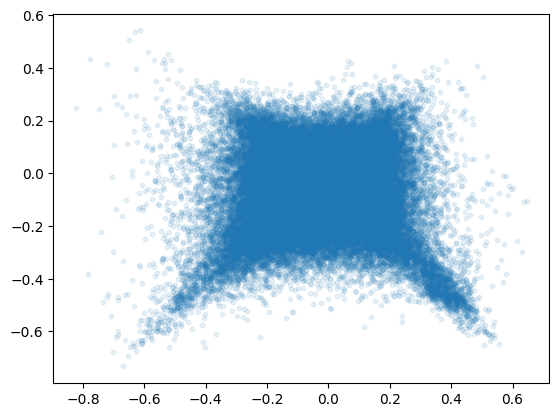

In [20]:
plt.scatter(
    valid_g["hedges_g_jacobian"],
    valid_g["hedges_g_weighted_degree"],
    alpha=0.1,
    s=10,
)

In [17]:
# Parcel-wise correspondence of effect sizes with sign ignored both ways (not t-statistics).
# The merge makes the comparison robust to any difference in row order.
hedges_comparison = (
    results_means_fine_grained[["parcel_id", "hedges_g"]]
    .merge(
        results_weighted_degree[["parcel_id", "hedges_g"]],
        on="parcel_id",
        suffixes=("_jacobian", "_weighted_degree"),
        validate="one_to_one",
    )
)

# Remove any parcels with infinite or NaN effect sizes, then compute correlations on absolute values

valid_g = hedges_comparison.replace([np.inf, -np.inf], np.nan).dropna()
pearson_g = stats.pearsonr(
    valid_g["hedges_g_jacobian"].abs(),
    valid_g["hedges_g_weighted_degree"].abs(),
)
spearman_g = stats.spearmanr(
    valid_g["hedges_g_jacobian"].abs(),
    valid_g["hedges_g_weighted_degree"].abs(),
)

print(f"Number of paired microparcels: {len(valid_g):,}")
print(f"Hedges' g Pearson r = {pearson_g.statistic:.4f} (p = {pearson_g.pvalue:.3e})")
print(f"Hedges' g Spearman rho = {spearman_g.statistic:.4f} (p = {spearman_g.pvalue:.3e})")


Number of paired microparcels: 83,442
Hedges' g Pearson r = 0.4931 (p = 0.000e+00)
Hedges' g Spearman rho = 0.3443 (p = 0.000e+00)
